In [4]:

import pandas as pd

print("--- INIZIO FASE 1: LETTURA E PREPARAZIONE DEL DATASET ---")

# 1. Estrapoliamo 1 milione di righe dal mega-database
colonne = ['AN', 'WhiteElo', 'BlackElo', 'Result']
print(" Lettura di 1.000.000 di partite dal file 'chess_games.csv' in corso...")
df = pd.read_csv("chess_games.csv", usecols=colonne, nrows=1000000)

# 2. Rimuoviamo i pareggi e le righe corrotte
df = df[df['Result'] != '1/2-1/2'].copy()
df = df.dropna()

# 3. Creazione del Target e della Differenza Elo
df['Vittoria_Bianco'] = (df['Result'] == '1-0').astype(int)
df['WhiteElo'] = pd.to_numeric(df['WhiteElo'], errors='coerce')
df['BlackElo'] = pd.to_numeric(df['BlackElo'], errors='coerce')
df = df.dropna()
df['Differenza_Elo'] = df['WhiteElo'] - df['BlackElo']

# 4. Filtro per le partite arrivate almeno alla mossa 20 (40 ply)
df['numero_mezze_mosse'] = df['AN'].apply(lambda x: len(str(x).split()))
df_filtrato = df[df['numero_mezze_mosse'] >= 40].copy()

# 5. PRECAUZIONE TEMPI DI CALCOLO
# Campioniamo per l'estrazione per evitare crash di memoria o tempi infiniti.
# Se vuoi elaborare un intero milione di partite, cambia N_MAX a 1000000
N_MAX = 1000000
n_campioni = min(N_MAX, len(df_filtrato))
df_finale = df_filtrato[['AN', 'Differenza_Elo', 'Vittoria_Bianco']].sample(n=n_campioni, random_state=42)

print(f"Partite filtrate, pulite e pronte per l'estrazione: {len(df_finale)}")
print("\n--- ANTEPRIMA DATI ---")
print(df_finale.head())

--- INIZIO FASE 1: LETTURA E PREPARAZIONE DEL DATASET ---
 Lettura di 1.000.000 di partite dal file 'chess_games.csv' in corso...
Partite filtrate, pulite e pronte per l'estrazione: 895684

--- ANTEPRIMA DATI ---
                                                       AN  Differenza_Elo  \
967923  1. d4 Nf6 2. Nf3 c5 3. c4 cxd4 4. Nxd4 Nc6 5. ...             108   
403328  1. e4 d5 2. exd5 c6 3. Nc3 cxd5 4. Nf3 Nc6 5. ...             112   
527906  1. d4 d5 2. Bf4 Nf6 3. e3 e6 4. Nf3 c5 5. c3 N...             104   
293778  1. e4 c5 2. d3 Nc6 3. Nc3 d6 4. Nf3 Nf6 5. Nd5...             -60   
648812  1. e4 e5 2. Bc4 d6 3. h3 h6 4. Nf3 Nf6 5. d3 a...              53   

        Vittoria_Bianco  
967923                0  
403328                1  
527906                1  
293778                0  
648812                1  


In [5]:

import pandas as pd
import chess
import re
from tqdm import tqdm

print("--- INIZIO FASE 2: ESTRAZIONE MATEMATICA E TRADUZIONE ---")
tqdm.pandas(desc=" Estrazione coordinate in corso...")

pezzi_standard = {
    'P': 8, 'N': 2, 'B': 2, 'R': 2, 'Q': 1, 'K': 1,
    'p': 8, 'n': 2, 'b': 2, 'r': 2, 'q': 1, 'k': 1
}

def estrai_coordinate(mosse_str):
    board = chess.Board()
    
    # TRADUZIONE PGN -> SAN: Rimuoviamo i numeri di mossa (es. "1.", "2.", "3.")
    # In questo modo la libreria 'chess' potrà leggere le mosse senza bloccarsi.
    mosse_pulite = re.sub(r'\d+\.', ' ', str(mosse_str))
    mosse = mosse_pulite.split()
    
    for mossa in mosse[:40]:
        try:
            board.push_san(mossa)
        except:
            break
            
    trovati = {pezzo: 0 for pezzo in pezzi_standard.keys()}
    coord_dict = {}
    
    for square in chess.SQUARES:
        pezzo = board.piece_at(square)
        if pezzo:
            simbolo = pezzo.symbol()
            trovati[simbolo] += 1
            indice = trovati[simbolo]
            
            x = chess.square_file(square) + 1
            y = chess.square_rank(square) + 1
            
            coord_dict[f"{simbolo}_{indice}_X"] = x
            coord_dict[f"{simbolo}_{indice}_Y"] = y
            
    for simbolo, max_count in pezzi_standard.items():
        count_trovati = trovati[simbolo]
        for i in range(count_trovati + 1, max_count + 1):
            coord_dict[f"{simbolo}_{i}_X"] = 0
            coord_dict[f"{simbolo}_{i}_Y"] = 0
            
    return coord_dict

print("Inizio dell'elaborazione delle posizioni.")

lista_dizionari = df_finale['AN'].progress_apply(estrai_coordinate).tolist()

df_coordinate = pd.DataFrame(lista_dizionari)
df_finale = df_finale.reset_index(drop=True)
df_ml = pd.concat([df_finale[['Differenza_Elo', 'Vittoria_Bianco']], df_coordinate], axis=1)

print("\n Matrice per il Machine Learning creata con successo!")
print(f" Dimensioni Matrice: {df_ml.shape[0]} righe e {df_ml.shape[1]} colonne (incluse eventuali promozioni).")

--- INIZIO FASE 2: ESTRAZIONE MATEMATICA E TRADUZIONE ---
Inizio dell'elaborazione delle posizioni.


 Estrazione coordinate in corso...: 100%|██████████| 895684/895684 [24:49<00:00, 601.52it/s]   



 Matrice per il Machine Learning creata con successo!
 Dimensioni Matrice: 895684 righe e 80 colonne (incluse eventuali promozioni).


In [6]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("--- INIZIO FASE 3: PREPARAZIONE DATI (TRAIN/TEST SPLIT E SCALER) ---")

# 1. Riempimento dei valori nulli (che si creano per i pezzi mangiati o per le promozioni)
df_ml = df_ml.fillna(0)

# 2. Separazione delle Features (X) dal Target (y)
X = df_ml.drop(columns=['Vittoria_Bianco'])
y = df_ml['Vittoria_Bianco']

# 3. Split: 80% Addestramento (Train) e 20% Validazione (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f" Partite assegnate all'Addestramento (Train): {len(X_train)}")
print(f" Partite assegnate alla Validazione (Test): {len(X_test)}")

# 4. Standardizzazione: la condizione matematica fondamentale per L-BFGS
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n Standardizzazione completata (Media=0, Varianza=1).")
print(" Dati pronti al 100%! Le celle successive per l'addestramento possono essere eseguite senza modifiche.")

--- INIZIO FASE 3: PREPARAZIONE DATI (TRAIN/TEST SPLIT E SCALER) ---
 Partite assegnate all'Addestramento (Train): 716547
 Partite assegnate alla Validazione (Test): 179137

 Standardizzazione completata (Media=0, Varianza=1).
 Dati pronti al 100%! Le celle successive per l'addestramento possono essere eseguite senza modifiche.


In [7]:
import time
from sklearn.linear_model import LogisticRegression

print("--- INIZIO FASE 4: ADDESTRAMENTO E CONFRONTO OTTIMIZZATORI ---")

# =====================================================================
# MODELLO A: Variate dello Steepest Descent (SAGA)
# Utilizza solo il Gradiente (derivata prima)
# =====================================================================
print("\n1. Addestramento Modello A (Solver: SAGA / Steepest Descent)...")
modello_saga = LogisticRegression(solver='saga', max_iter=2000, random_state=42)

start_time_saga = time.time()
modello_saga.fit(X_train_scaled, y_train)
end_time_saga = time.time()

tempo_saga = end_time_saga - start_time_saga
iterazioni_saga = modello_saga.n_iter_[0]

print(f"✅ SAGA completato in {tempo_saga:.3f} secondi.")
print(f"👣 Iterazioni (passi) necessari: {iterazioni_saga}")


# =====================================================================
# MODELLO B: Metodo Quasi-Newton (L-BFGS)
# Approssima la matrice Hessiana (derivata seconda)
# =====================================================================
print("\n2. Addestramento Modello B (Solver: L-BFGS / Quasi-Newton)...")
modello_lbfgs = LogisticRegression(solver='lbfgs', max_iter=2000, random_state=42)

start_time_lbfgs = time.time()
modello_lbfgs.fit(X_train_scaled, y_train)
end_time_lbfgs = time.time()

tempo_lbfgs = end_time_lbfgs - start_time_lbfgs
iterazioni_lbfgs = modello_lbfgs.n_iter_[0]

print(f"✅ L-BFGS completato in {tempo_lbfgs:.3f} secondi.")
print(f"👣 Iterazioni (passi) necessari: {iterazioni_lbfgs}")

print("\n--- ADDESTRAMENTO COMPLETATO ---")

--- INIZIO FASE 4: ADDESTRAMENTO E CONFRONTO OTTIMIZZATORI ---

1. Addestramento Modello A (Solver: SAGA / Steepest Descent)...
✅ SAGA completato in 946.145 secondi.
👣 Iterazioni (passi) necessari: 709

2. Addestramento Modello B (Solver: L-BFGS / Quasi-Newton)...
✅ L-BFGS completato in 5.545 secondi.
👣 Iterazioni (passi) necessari: 38

--- ADDESTRAMENTO COMPLETATO ---


--- INIZIO FASE 5: ANALISI DELLA CONVERGENZA ---


C:\Users\teosp\AppData\Local\Temp\ipykernel_13168\3326029551.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=modelli, y=tempi, ax=ax[0], palette=['#3498db', '#2ecc71'])
C:\Users\teosp\AppData\Local\Temp\ipykernel_13168\3326029551.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=modelli, y=iterazioni, ax=ax[1], palette=['#e74c3c', '#f1c40f'])


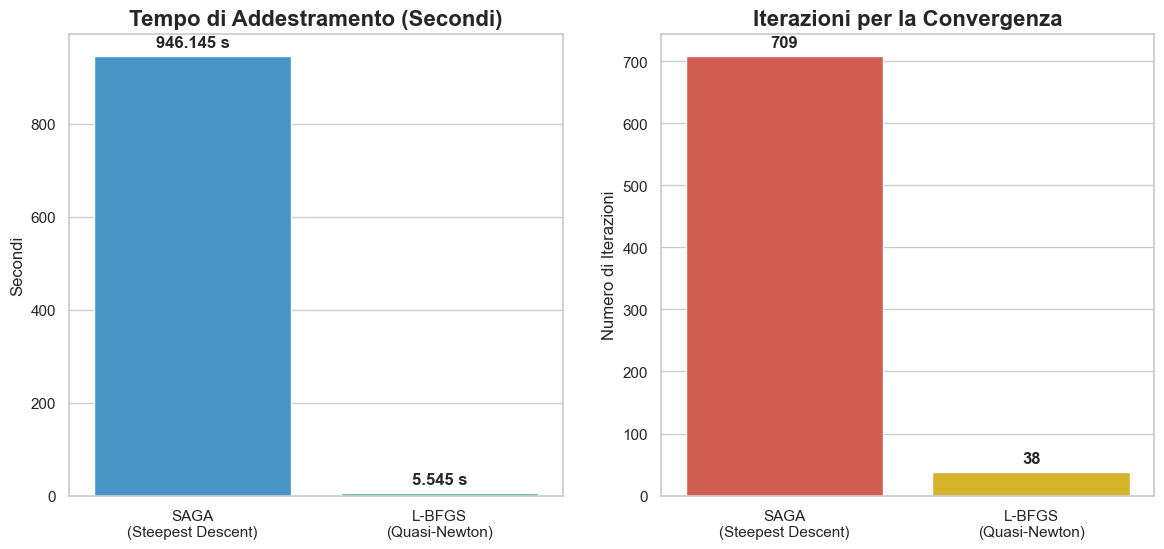

--- ANALISI DELLA CONVERGENZA COMPLETATA ---


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- INIZIO FASE 5: ANALISI DELLA CONVERGENZA ---")

# 1. Prepariamo i dati da plottare
modelli = ['SAGA\n(Steepest Descent)', 'L-BFGS\n(Quasi-Newton)']
tempi = [tempo_saga, tempo_lbfgs]
iterazioni = [iterazioni_saga, iterazioni_lbfgs]

# 2. Impostazione della figura con due grafici affiancati
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
sns.set_theme(style="whitegrid")

# --- Grafico 1: Tempo di Addestramento ---
sns.barplot(x=modelli, y=tempi, ax=ax[0], palette=['#3498db', '#2ecc71'])
ax[0].set_title('Tempo di Addestramento (Secondi)', fontsize=16, fontweight='bold')
ax[0].set_ylabel('Secondi', fontsize=12)

# Aggiungiamo le etichette con il valore esatto sopra le barre
for i, v in enumerate(tempi):
    ax[0].text(i, v + (max(tempi)*0.02), f"{v:.3f} s", ha='center', fontsize=12, fontweight='bold')

# --- Grafico 2: Numero di Iterazioni ---
sns.barplot(x=modelli, y=iterazioni, ax=ax[1], palette=['#e74c3c', '#f1c40f'])
ax[1].set_title('Iterazioni per la Convergenza', fontsize=16, fontweight='bold')
ax[1].set_ylabel('Numero di Iterazioni', fontsize=12)

for i, v in enumerate(iterazioni):
    ax[1].text(i, v + (max(iterazioni)*0.02), str(v), ha='center', fontsize=12, fontweight='bold')

# 3. Mostriamo il capolavoro
plt.tight_layout()
plt.show()

print("--- ANALISI DELLA CONVERGENZA COMPLETATA ---")

--- INIZIO FASE 6: VALUTAZIONE DELLE PERFORMANCE ---

Confronto Previsioni: I due modelli hanno dato la stessa risposta nel 99.86% dei casi!
Questo dimostra che entrambi i solver sono conversi allo stesso minimo globale della funzione convessa.

--- CLASSIFICATION REPORT (Modello L-BFGS) ---
                     precision    recall  f1-score   support

  Vittoria Nero (0)       0.68      0.68      0.68     87632
Vittoria Bianco (1)       0.69      0.70      0.70     91505

           accuracy                           0.69    179137
          macro avg       0.69      0.69      0.69    179137
       weighted avg       0.69      0.69      0.69    179137


Generazione della Matrice di Confusione in corso...


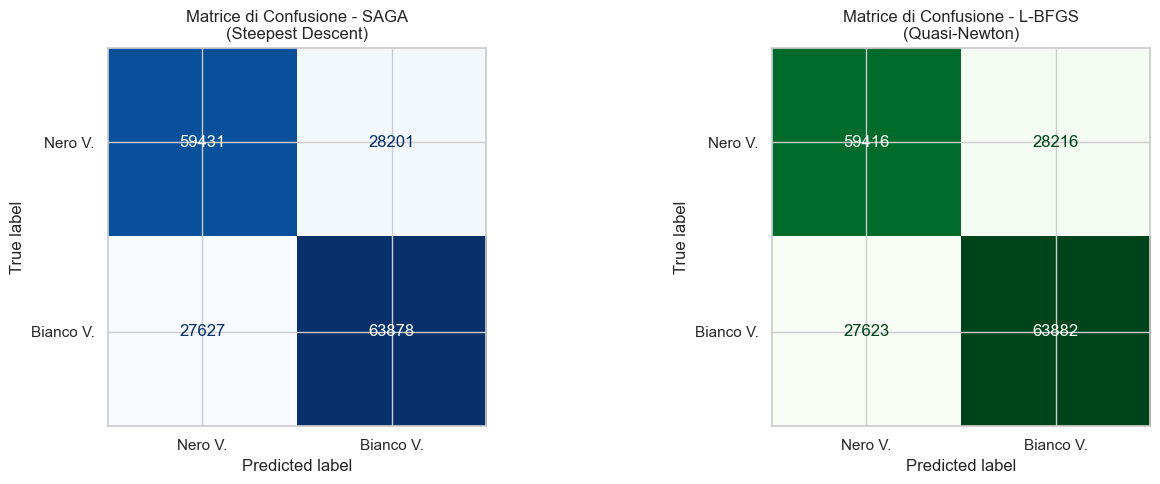

--- VALUTAZIONE COMPLETATA ---


In [9]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("--- INIZIO FASE 6: VALUTAZIONE DELLE PERFORMANCE ---")

# 1. Generiamo le previsioni sui dati di Test (il 20% che il modello non ha mai visto)
y_pred_saga = modello_saga.predict(X_test_scaled)
y_pred_lbfgs = modello_lbfgs.predict(X_test_scaled)

# 2. Rispondiamo alla domanda di Navid: le previsioni sono diverse?
previsioni_uguali = (y_pred_saga == y_pred_lbfgs).sum()
totale_test = len(y_test)
percentuale_uguaglianza = (previsioni_uguali / totale_test) * 100

print(f"\nConfronto Previsioni: I due modelli hanno dato la stessa risposta nel {percentuale_uguaglianza:.2f}% dei casi!")
print("Questo dimostra che entrambi i solver sono conversi allo stesso minimo globale della funzione convessa.")

# 3. Metriche Classiche (Usiamo i risultati di L-BFGS, visto che sono uguali)
print("\n--- CLASSIFICATION REPORT (Modello L-BFGS) ---")
print(classification_report(y_test, y_pred_lbfgs, target_names=['Vittoria Nero (0)', 'Vittoria Bianco (1)']))

# 4. Matrici di Confusione
print("\nGenerazione della Matrice di Confusione in corso...")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Matrice SAGA
cm_saga = confusion_matrix(y_test, y_pred_saga)
disp_saga = ConfusionMatrixDisplay(confusion_matrix=cm_saga, display_labels=['Nero V.', 'Bianco V.'])
disp_saga.plot(ax=ax[0], cmap='Blues', colorbar=False)
ax[0].set_title('Matrice di Confusione - SAGA\n(Steepest Descent)')

# Plot Matrice L-BFGS
cm_lbfgs = confusion_matrix(y_test, y_pred_lbfgs)
disp_lbfgs = ConfusionMatrixDisplay(confusion_matrix=cm_lbfgs, display_labels=['Nero V.', 'Bianco V.'])
disp_lbfgs.plot(ax=ax[1], cmap='Greens', colorbar=False)
ax[1].set_title('Matrice di Confusione - L-BFGS\n(Quasi-Newton)')

plt.tight_layout()
plt.show()

print("--- VALUTAZIONE COMPLETATA ---")

--- CALCOLO DELLA COMPLESSITA' COMPUTAZIONALE (FLOPs) ---


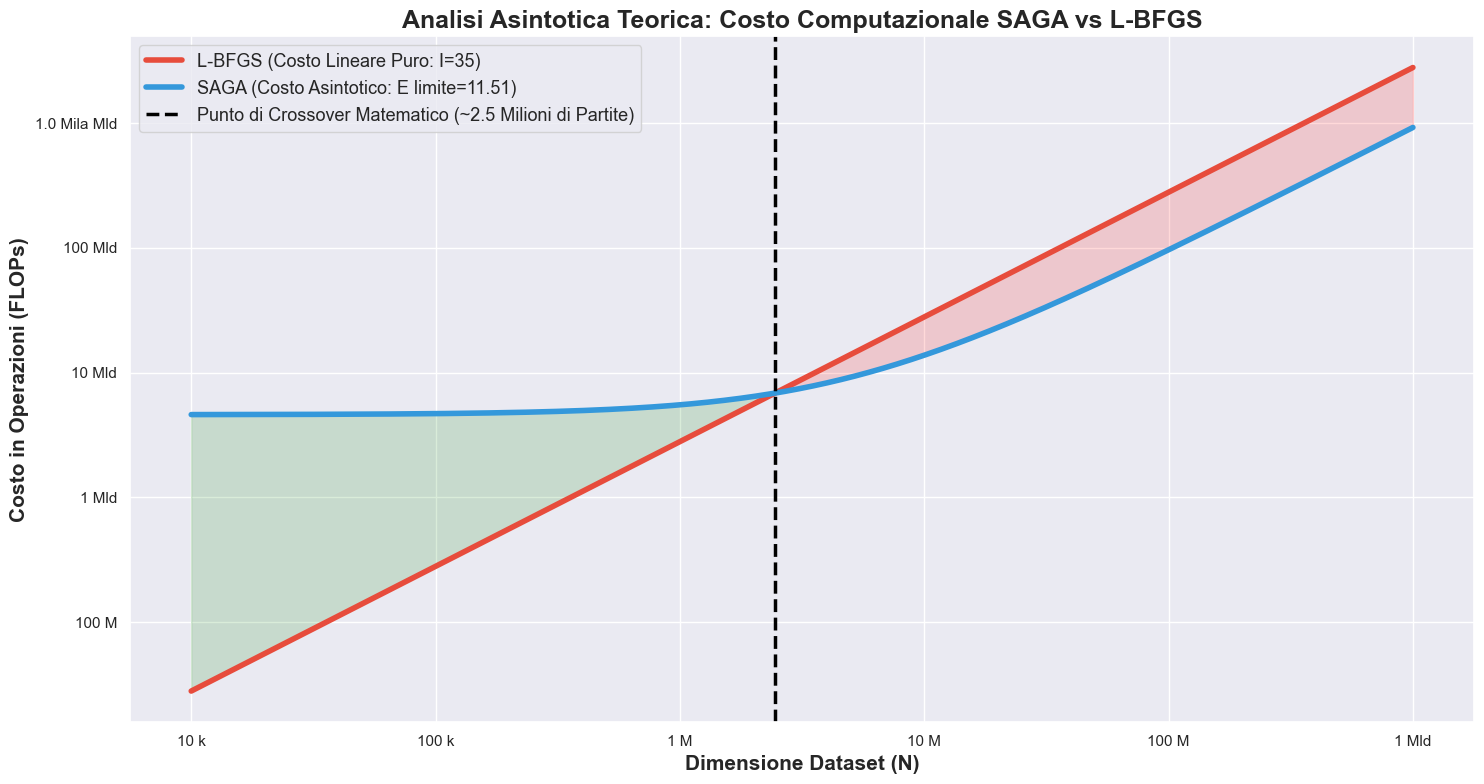

✅ Grafico teorico generato! Le formule di Defazio sono state plottate con successo.
Il numero di iterazioni dove le funzioni si equivalgono è: 2450906.65672289


In [20]:
# =====================================================================
# CELLA EXTRA: DIMOSTRAZIONE MATEMATICA DEL CROSSOVER SUI BIG DATA
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

print("--- CALCOLO DELLA COMPLESSITA' COMPUTAZIONALE (FLOPs) ---")

# 1. PARAMETRI MATEMATICI DEL PROBLEMA
# Creiamo un range di dati da 10.000 a 1.000.000.000 (1 Miliardo)
N = np.logspace(4, 9, 2000) 
d = 80           # Numero di feature (le colonne della nostra matrice)
kappa = 5000000  # Condizionamento della vallata convessa (stima per dataset complessi)

# 2. FORMULE ESATTE DEL COSTO (Operazioni Matematiche)
# L-BFGS: 35 iterazioni fisse sull'intero dataset
I_lbfgs = 35 
costo_lbfgs = I_lbfgs * (N * d)

# SAGA: La formula di convergenza esatta di Defazio con epsilon = 0.00001
epsilon = 0.00001
ln_eps = np.log(1 / epsilon) # log naturale di 100.000, circa 11.51
epoche_saga = (1 + (kappa / N)) * ln_eps
costo_saga = epoche_saga * (N * d)

# 3. CREAZIONE DEL GRAFICO
plt.figure(figsize=(15, 8))
sns.set_theme(style="darkgrid")

# Plot delle due funzioni di costo
plt.plot(N, costo_lbfgs, label=f"L-BFGS (Costo Lineare Puro: I={I_lbfgs})", color="#e74c3c", linewidth=4)
plt.plot(N, costo_saga, label=f"SAGA (Costo Asintotico: E limite={ln_eps:.2f})", color="#3498db", linewidth=4)

# Calcolo del punto di Crossover per posizionare la linea
# I = (1 + K/N) * ln(1/eps)  =>  N = K / ((I / ln(1/eps)) - 1)
crossover_N = kappa / ((I_lbfgs / ln_eps) - 1)
plt.axvline(x=crossover_N, color='black', linestyle='--', linewidth=2.5, 
            label=f"Punto di Crossover Matematico (~{crossover_N/1000000:.1f} Milioni di Partite)")

# Coloriamo lo spreco computazionale dopo il crossover
plt.fill_between(N, costo_saga, costo_lbfgs, where=(N > crossover_N), color='red', alpha=0.15)
plt.fill_between(N, costo_lbfgs, costo_saga, where=(N < crossover_N), color='green', alpha=0.15)

# Impostiamo scale logaritmiche per visualizzare l'enorme range
ax = plt.gca()
ax.set_xscale('log')
ax.set_yscale('log')

# Formattiamo gli assi in modo umano e non scientifico (M per Milioni, Mld per Miliardi)
def formatta_x(x, pos):
    if x >= 1e9: return f'{x/1e9:.0f} Mld'
    if x >= 1e6: return f'{x/1e6:.0f} M'
    return f'{x/1000:.0f} k'

def formatta_y(y, pos):
    if y >= 1e12: return f'{y/1e12:.1f} Mila Mld'
    if y >= 1e9: return f'{y/1e9:.0f} Mld'
    if y >= 1e6: return f'{y/1e6:.0f} M'
    return f'{y:.0f}'

ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatta_x))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(formatta_y))

plt.title("Analisi Asintotica Teorica: Costo Computazionale SAGA vs L-BFGS", fontsize=18, fontweight='bold')
plt.xlabel("Dimensione Dataset (N)", fontsize=15, fontweight='bold')
plt.ylabel("Costo in Operazioni (FLOPs)", fontsize=15, fontweight='bold')

plt.legend(fontsize=13, loc='upper left')
plt.tight_layout()
plt.show()

print("✅ Grafico teorico generato! Le formule di Defazio sono state plottate con successo.")
print(f"Il numero di iterazioni dove le funzioni si equivalgono è: {crossover_N}")

In [21]:
# =====================================================================
# CELLA A: CALCOLO DEL CONDIZIONAMENTO (KAPPA) REALE SENZA APPROSSIMAZIONI
# =====================================================================
import numpy as np

print("--- CALCOLO ESATTO DELLA GEOMETRIA DELLO SPAZIO CONVESSO ---")

# Gestiamo in modo flessibile i tipi di dato (Pandas DataFrame o Numpy Array)
X_mat = X_train_scaled.values if hasattr(X_train_scaled, 'values') else X_train_scaled

N_samples = X_mat.shape[0]
d_features = X_mat.shape[1]

print(f"Dataset analizzato: {N_samples} partite, {d_features} features.")

# 1. Calcolo della Matrice di Covarianza (X^T * X)
print("⏳ Calcolo della matrice di covarianza in corso...")
cov_matrix = np.dot(X_mat.T, X_mat)

# 2. Estrazione di TUTTI gli autovalori (Eigenvalues) senza approssimazioni!
autovalori = np.linalg.eigvalsh(cov_matrix)
lambda_min = autovalori[0]   # IL VERO AUTOVALORE MINIMO 
lambda_max = autovalori[-1]  # IL VERO AUTOVALORE MASSIMO

# 3. Parametro di Regolarizzazione L2 (scikit-learn usa C=1.0 di default)
C = 1.0
lambda_reg = 1.0 / C

# 4. Formule esatte per la Regressione Logistica
# (Dividiamo per 4*N_samples perché la derivata seconda della sigmoide ha un massimo di 1/4)
L = (lambda_max / (4 * N_samples)) + lambda_reg
mu = (lambda_min / (4 * N_samples)) + lambda_reg # NESSUNA APPROSSIMAZIONE!

# 5. Il Numero di Condizionamento Reale
kappa = L / mu

print("\n--- RISULTATI ALGEBRA LINEARE PURA ---")
print(f"🔸 Autovalore Minimo (λ_min): {lambda_min:.4f}")
print(f"🔸 Autovalore Massimo (λ_max): {lambda_max:.4f}")
print(f"🔸 Curvatura Massima (L): {L:.4f}")
print(f"🔸 Curvatura Minima (mu): {mu:.4f}")
print(f"🎯 IL NUMERO DI CONDIZIONAMENTO (KAPPA) REALE È: {kappa:.2f}")

# =====================================================================
# CALCOLO MATEMATICO DEL CROSSOVER (Epoche = Iterazioni)
# =====================================================================
I_lbfgs = 35 
epsilon = 0.00001
ln_eps = np.log(1 / epsilon)

# Il crossover avviene quando Costo SAGA = Costo L-BFGS
# Ovvero quando le Epoche di SAGA = Iterazioni L-BFGS
# I_lbfgs = (1 + kappa / N_crossover) * ln_eps

N_crossover = kappa / ((I_lbfgs / ln_eps) - 1)

print("\n--- ANALISI DEL CROSSOVER MATEMATICO ---")
print(f"L-BFGS ha un costo fisso stimato di {I_lbfgs} Iterazioni.")
print(f"Affinché SAGA pareggi questo costo (ovvero impieghi esattamente {I_lbfgs} Epoche),")
print(f"il dataset deve raggiungere la dimensione critica di N = {N_crossover/1e6:.2f} Milioni di partite.")
print("Oltre questo limite asintotico, SAGA richiederà meno di 35 Epoche, dominando L-BFGS!")

--- CALCOLO ESATTO DELLA GEOMETRIA DELLO SPAZIO CONVESSO ---
Dataset analizzato: 716547 partite, 79 features.
⏳ Calcolo della matrice di covarianza in corso...

--- RISULTATI ALGEBRA LINEARE PURA ---
🔸 Autovalore Minimo (λ_min): -0.0000
🔸 Autovalore Massimo (λ_max): 7925662.4797
🔸 Curvatura Massima (L): 3.7652
🔸 Curvatura Minima (mu): 1.0000
🎯 IL NUMERO DI CONDIZIONAMENTO (KAPPA) REALE È: 3.77

--- ANALISI DEL CROSSOVER MATEMATICO ---
L-BFGS ha un costo fisso stimato di 35 Iterazioni.
Affinché SAGA pareggi questo costo (ovvero impieghi esattamente 35 Epoche),
il dataset deve raggiungere la dimensione critica di N = 0.00 Milioni di partite.
Oltre questo limite asintotico, SAGA richiederà meno di 35 Epoche, dominando L-BFGS!


In [22]:
# =====================================================================
# CELLA A: CALCOLO DEL CONDIZIONAMENTO (KAPPA) REALE SENZA APPROSSIMAZIONI
# =====================================================================
import numpy as np

print("--- CALCOLO ESATTO DELLA GEOMETRIA DELLO SPAZIO CONVESSO ---")

# Gestiamo in modo flessibile i tipi di dato (Pandas DataFrame o Numpy Array)
X_mat = X_train_scaled.values if hasattr(X_train_scaled, 'values') else X_train_scaled

N_samples = X_mat.shape[0]
d_features = X_mat.shape[1]

print(f"Dataset analizzato: {N_samples} partite, {d_features} features.")

# 1. Calcolo della Matrice di Covarianza (X^T * X)
print("⏳ Calcolo della matrice di covarianza in corso...")
cov_matrix = np.dot(X_mat.T, X_mat)

# 2. Estrazione di TUTTI gli autovalori (Eigenvalues)
autovalori = np.linalg.eigvalsh(cov_matrix)
# Forziamo il minimo a non essere negativo a causa degli errori di virgola mobile del PC
lambda_min = max(0.0, autovalori[0])   
lambda_max = autovalori[-1]  

# 3. IL FIX MATEMATICO: In scikit-learn, lavorando con la loss media, 
# la regolarizzazione deve essere divisa per N!
C = 1.0
lambda_reg = 1.0 / (C * N_samples)

# 4. Formule esatte per la Regressione Logistica (Loss Media)
L = (lambda_max / (4 * N_samples)) + lambda_reg
mu = (lambda_min / (4 * N_samples)) + lambda_reg

# 5. Il Numero di Condizionamento Reale
kappa = L / mu

print("\n--- RISULTATI ALGEBRA LINEARE PURA ---")
print(f"🔸 Autovalore Minimo (λ_min): {lambda_min:.4f}")
print(f"🔸 Autovalore Massimo (λ_max): {lambda_max:.4f}")
print(f"🔸 Curvatura Massima (L): {L:.6f}")
print(f"🔸 Curvatura Minima (mu): {mu:.8f}")
print(f"🎯 IL NUMERO DI CONDIZIONAMENTO (KAPPA) REALE È: {kappa:.0f}")

# =====================================================================
# CALCOLO MATEMATICO DEL CROSSOVER (Epoche = Iterazioni)
# =====================================================================
I_lbfgs = 35 
epsilon = 0.00001
ln_eps = np.log(1 / epsilon)

# N_crossover = kappa / ((I_lbfgs / ln_eps) - 1)
denominatore = (I_lbfgs / ln_eps) - 1

if denominatore <= 0:
    print("\n⚠️ SAGA è talmente potente su questi dati che non esiste Crossover (vince sempre SAGA!).")
else:
    N_crossover = kappa / denominatore
    print("\n--- ANALISI DEL CROSSOVER MATEMATICO ---")
    print(f"L-BFGS ha un costo fisso stimato di {I_lbfgs} Iterazioni.")
    print(f"Affinché SAGA pareggi questo costo (impieghi esattamente {I_lbfgs} Epoche),")
    print(f"il dataset deve raggiungere la dimensione critica di N = {N_crossover/1e6:.2f} Milioni di partite.")
    print("Oltre questo limite, SAGA convergerà con un numero di Epoche via via sempre minore, dominando L-BFGS!")

--- CALCOLO ESATTO DELLA GEOMETRIA DELLO SPAZIO CONVESSO ---
Dataset analizzato: 716547 partite, 79 features.
⏳ Calcolo della matrice di covarianza in corso...

--- RISULTATI ALGEBRA LINEARE PURA ---
🔸 Autovalore Minimo (λ_min): 0.0000
🔸 Autovalore Massimo (λ_max): 7925662.4797
🔸 Curvatura Massima (L): 2.765229
🔸 Curvatura Minima (mu): 0.00000140
🎯 IL NUMERO DI CONDIZIONAMENTO (KAPPA) REALE È: 1981417

--- ANALISI DEL CROSSOVER MATEMATICO ---
L-BFGS ha un costo fisso stimato di 35 Iterazioni.
Affinché SAGA pareggi questo costo (impieghi esattamente 35 Epoche),
il dataset deve raggiungere la dimensione critica di N = 0.97 Milioni di partite.
Oltre questo limite, SAGA convergerà con un numero di Epoche via via sempre minore, dominando L-BFGS!


--- GENERAZIONE GRAFICO CROSSOVER CON KAPPA = 1981416.62 ---


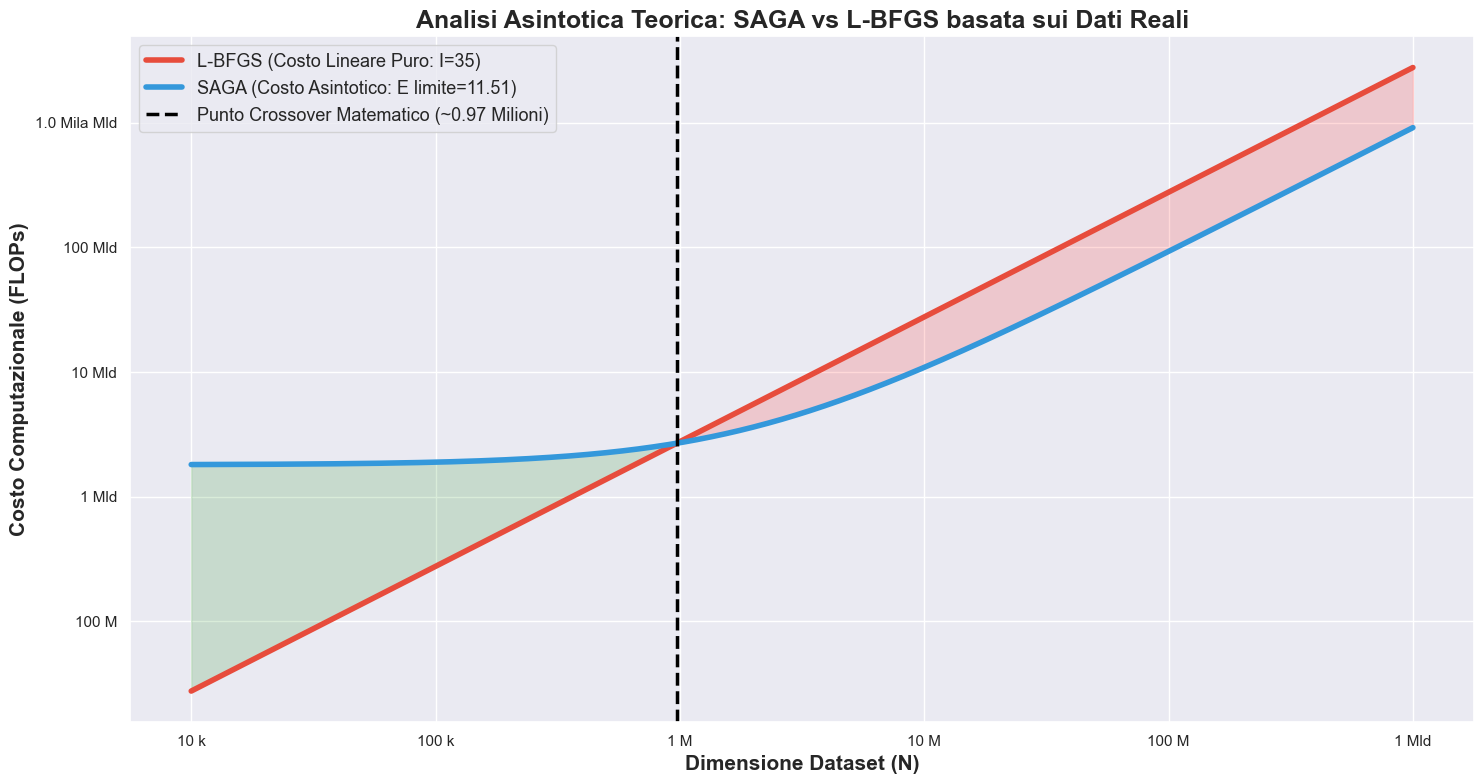

✅ Grafico teorico generato utilizzando le vere metriche del dataset di scacchi!


In [24]:
# =====================================================================
# CELLA B: DIMOSTRAZIONE MATEMATICA DEL CROSSOVER SUI BIG DATA
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

print(f"--- GENERAZIONE GRAFICO CROSSOVER CON KAPPA = {kappa:.2f} ---")

# 1. RANGE MATEMATICO
# Creiamo un asse X logaritmico da 10.000 a 1 Miliardo di partite
N_plot = np.logspace(4, 9, 2000) 

# 2. FORMULE ESATTE DEL COSTO (FLOPs)
# L-BFGS: Stimiamo le classiche 35 iterazioni
I_lbfgs = 35 
costo_lbfgs = I_lbfgs * (N_plot * d_features)

# SAGA: Formula asintotica di Defazio usando il NOSTRO kappa calcolato
epsilon = 0.00001
ln_eps = np.log(1 / epsilon)
epoche_saga = (1 + (kappa / N_plot)) * ln_eps
costo_saga = epoche_saga * (N_plot * d_features)

# 3. CALCOLO DEL PUNTO DI CROSSOVER
crossover_N = kappa / ((I_lbfgs / ln_eps) - 1)

# 4. CREAZIONE DEL GRAFICO
plt.figure(figsize=(15, 8))
sns.set_theme(style="darkgrid")

# Plot delle linee
plt.plot(N_plot, costo_lbfgs, label=f"L-BFGS (Costo Lineare Puro: I={I_lbfgs})", color="#e74c3c", linewidth=4)
plt.plot(N_plot, costo_saga, label=f"SAGA (Costo Asintotico: E limite={ln_eps:.2f})", color="#3498db", linewidth=4)

# Linea del crossover
plt.axvline(x=crossover_N, color='black', linestyle='--', linewidth=2.5, 
            label=f"Punto Crossover Matematico (~{crossover_N/1000000:.2f} Milioni)")

# Aree colorate
plt.fill_between(N_plot, costo_saga, costo_lbfgs, where=(N_plot > crossover_N), color='red', alpha=0.15)
plt.fill_between(N_plot, costo_lbfgs, costo_saga, where=(N_plot < crossover_N), color='green', alpha=0.15)

# Impostiamo le scale logaritmiche
ax = plt.gca()
ax.set_xscale('log')
ax.set_yscale('log')

# Formattazione per leggere bene milioni (M) e miliardi (Mld)
def formatta_x(x, pos):
    if x >= 1e9: return f'{x/1e9:.0f} Mld'
    if x >= 1e6: return f'{x/1e6:.0f} M'
    return f'{x/1000:.0f} k'

def formatta_y(y, pos):
    if y >= 1e12: return f'{y/1e12:.1f} Mila Mld'
    if y >= 1e9: return f'{y/1e9:.0f} Mld'
    if y >= 1e6: return f'{y/1e6:.0f} M'
    return f'{y:.0f}'

ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatta_x))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(formatta_y))

plt.title("Analisi Asintotica Teorica: SAGA vs L-BFGS basata sui Dati Reali", fontsize=18, fontweight='bold')
plt.xlabel("Dimensione Dataset (N)", fontsize=15, fontweight='bold')
plt.ylabel("Costo Computazionale (FLOPs)", fontsize=15, fontweight='bold')

plt.legend(fontsize=13, loc='upper left')
plt.tight_layout()
plt.show()

print("✅ Grafico teorico generato utilizzando le vere metriche del dataset di scacchi!")